In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("08-seismic_activity_svm.csv")

In [3]:
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


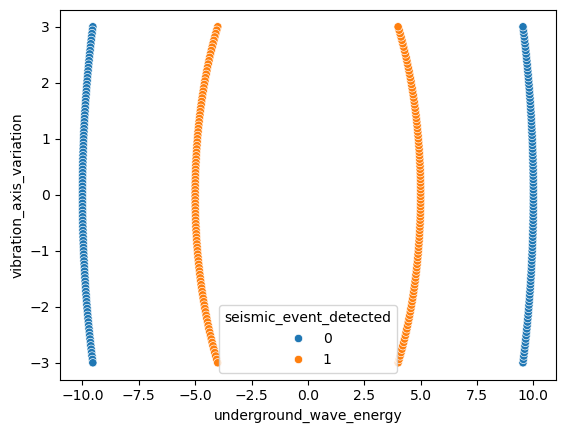

In [4]:
sns.scatterplot(x=df["underground_wave_energy"], y=df["vibration_axis_variation"], hue=df["seismic_event_detected"])
plt.show()

In [5]:
X = torch.tensor(df[["underground_wave_energy","vibration_axis_variation"]].values,dtype=torch.float32)
Y = torch.tensor(df["seismic_event_detected"],dtype=torch.float32)

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y,train_size=0.8,test_size=0.2)

In [7]:
Y_train = torch.tensor(Y_train, dtype = torch.float32).unsqueeze(1)
Y_test = torch.tensor(Y_test, dtype = torch.float32).unsqueeze(1)


/var/folders/yq/9bl15n6s1d50gn4f0qbzg_7w0000gn/T/ipykernel_24993/2610969514.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_train = torch.tensor(Y_train, dtype = torch.float32).unsqueeze(1)
/var/folders/yq/9bl15n6s1d50gn4f0qbzg_7w0000gn/T/ipykernel_24993/2610969514.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_test = torch.tensor(Y_test, dtype = torch.float32).unsqueeze(1)


In [8]:
class ClassificationModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = torch.nn.Linear(in_features=2,out_features=10)
        self.layer2 = torch.nn.Linear(in_features=10,out_features=10)
        self.layer3 = torch.nn.Linear(in_features=10,out_features=1)
    def forward(self, x) -> torch.tensor:
        return self.layer3(self.layer2(self.layer1(x)))

In [9]:
model_0 = ClassificationModel()

In [10]:
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.001)

In [11]:
torch.manual_seed(42)
epochs = 80

In [12]:
for epoch in range(epochs):
    model_0.train()

    Y_logits = model_0(X_train)

    loss = loss_fn(Y_logits,Y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch==79:
        print("bitti)")
    
    

bitti)


In [13]:
model_0.eval()
print(model_0(torch.tensor([9.539392,-3.000000])))

tensor([0.2005], grad_fn=<ViewBackward0>)


In [14]:
import numpy as np

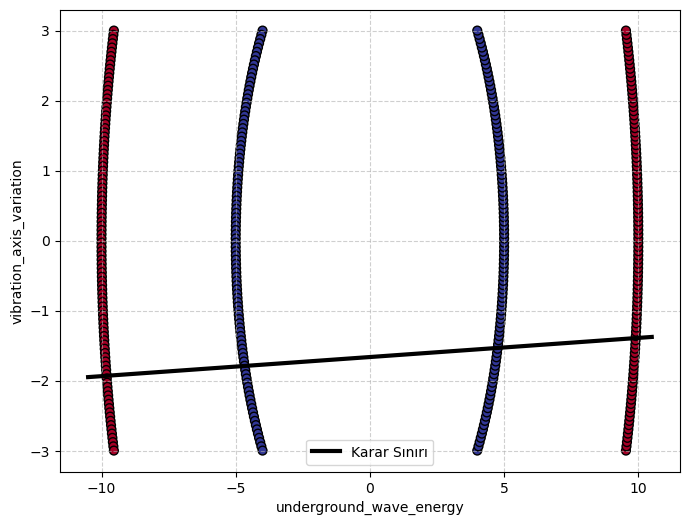

In [15]:
def plot_linear_decision_boundary_3layers(model, X, y):
    # 1. Önce değişkenleri çek (model.layer1, layer2, layer3 olarak)
    W1 = model.layer1.weight.detach().numpy()
    b1 = model.layer1.bias.detach().numpy()
    
    W2 = model.layer2.weight.detach().numpy()
    b2 = model.layer2.bias.detach().numpy()
    
    W3 = model.layer3.weight.detach().numpy()
    b3 = model.layer3.bias.detach().numpy()

    # 2. Efektif W ve b hesaplama (Doğrusal modellerde katmanları çarparak teke indirgeyebiliriz)
    # W_eff = W3 * W2 * W1
    W_eff = W3 @ W2 @ W1
    w1, w2 = W_eff[0]

    # Efektif bias: Her katmanın bias'ını bir sonraki katmanın ağırlığıyla çarpıp ekliyoruz
    b_eff = (W3 @ (W2 @ b1 + b2) + b3)[0]

    # 3. Çizim için X aralığını belirle
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    xs = np.linspace(x_min, x_max, 200)

    # w1*x1 + w2*x2 + b = 0  => x2 = -(w1*x1 + b) / w2
    ys = -(w1 * xs + b_eff) / w2

    # 4. Görselleştirme
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=40, edgecolors='k')
    plt.plot(xs, ys, "k-", linewidth=3, label="Karar Sınırı")
    plt.xlabel("underground_wave_energy")
    plt.ylabel("vibration_axis_variation")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

# En son bu fonksiyonu çağır:
plot_linear_decision_boundary_3layers(model_0, X, Y)